# Letterboxd Recommender — Exploratory Data Analysis
WGU C964 Task 2 | João Vítor Fernandes

In [1]:
import sys
sys.path.insert(0, '../backend')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Dataset Overview

In [2]:
raw = pd.read_csv('../data/imdb_top_1000.csv')
clean = pd.read_csv('../data/movies_clean.csv')
print(f'Raw rows: {len(raw)} → Clean rows: {len(clean)}')
print(f'Dropped: {len(raw)-len(clean)} (TV series / missing critical fields)')
clean.head(3)

Raw rows: 1000 → Clean rows: 999
Dropped: 1 (TV series / missing critical fields)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,...,Star4,No_of_Votes,primary_genre,Gross_log,movie_id,fe_Director,fe_Star1,fe_Star2,fe_Star3,fe_Star4
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,...,William Sadler,2343110,Drama,17.159837,0,0.002002,0.001001,0.001001,0.001001,0.001001
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,...,Diane Keaton,1620367,Crime,18.720537,1,0.005005,0.002002,0.003003,0.001001,0.002002
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,...,Michael Caine,2303232,Action,20.097513,2,0.008008,0.008008,0.002002,0.001001,0.004004


In [3]:
print('Null counts (clean dataset):')
print(clean.isnull().sum()[clean.isnull().sum() > 0])

Null counts (clean dataset):
Certificate    101
dtype: int64


## 2. Feature Distributions

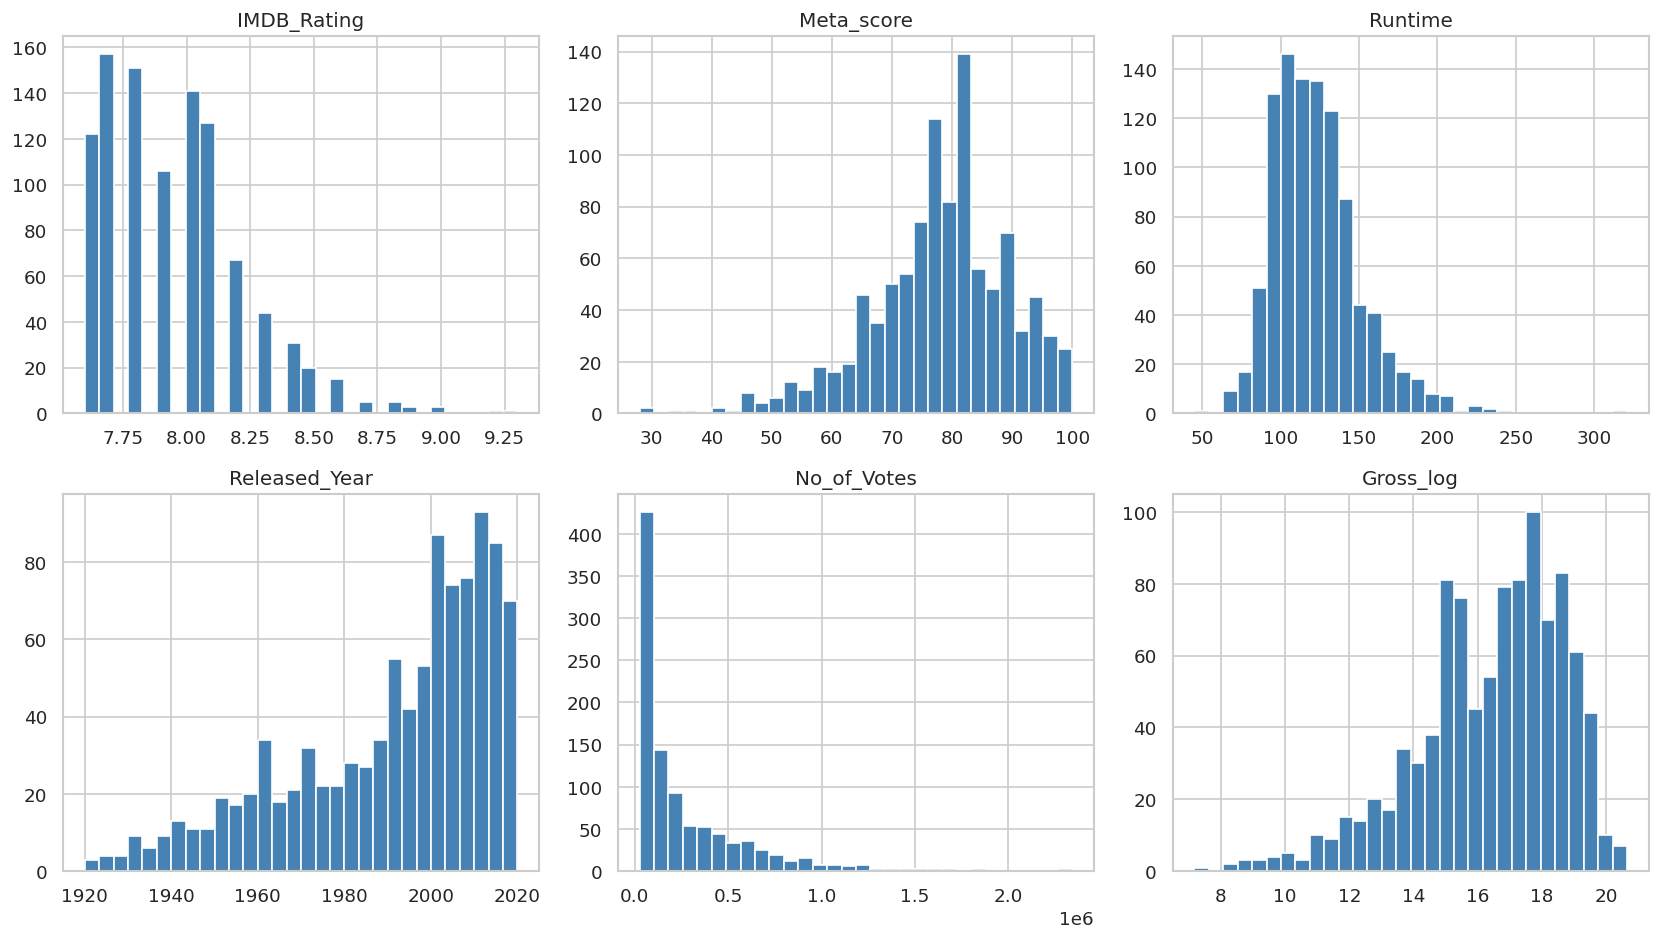

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, ['IMDB_Rating','Meta_score','Runtime','Released_Year','No_of_Votes','Gross_log']):
    clean[col].dropna().hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', bbox_inches='tight')
plt.show()

## 3. Genre Distribution

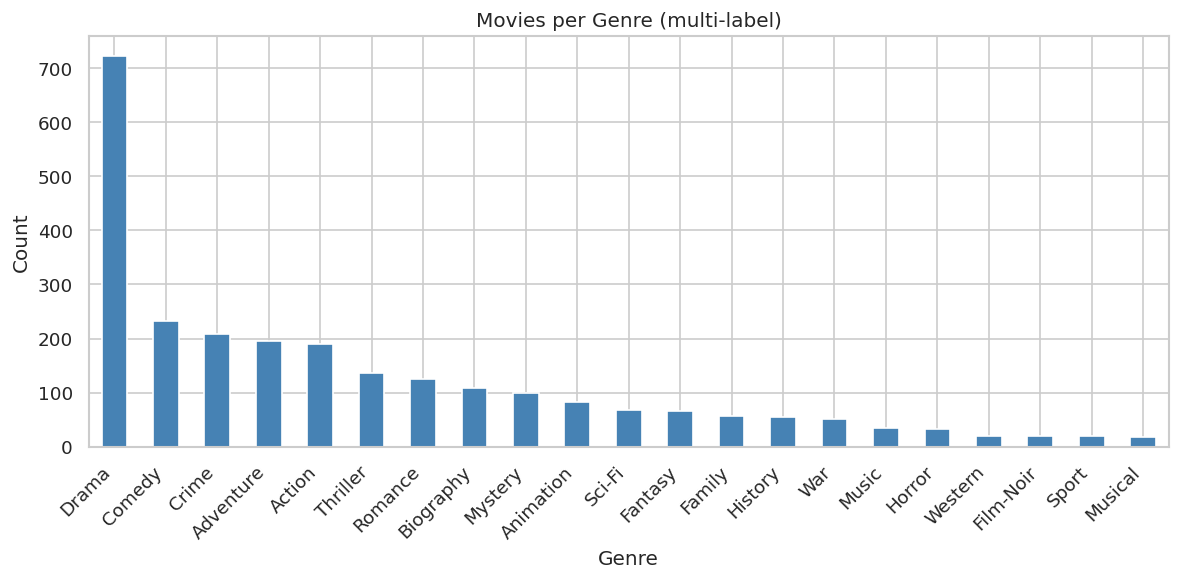

In [5]:
genre_counts = (
    clean['Genre'].str.split(r',\s*').explode().str.strip()
    .value_counts()
)
fig, ax = plt.subplots(figsize=(10, 5))
genre_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Movies per Genre (multi-label)')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/genre_distribution.png', bbox_inches='tight')
plt.show()

## 4. Synthetic User Statistics

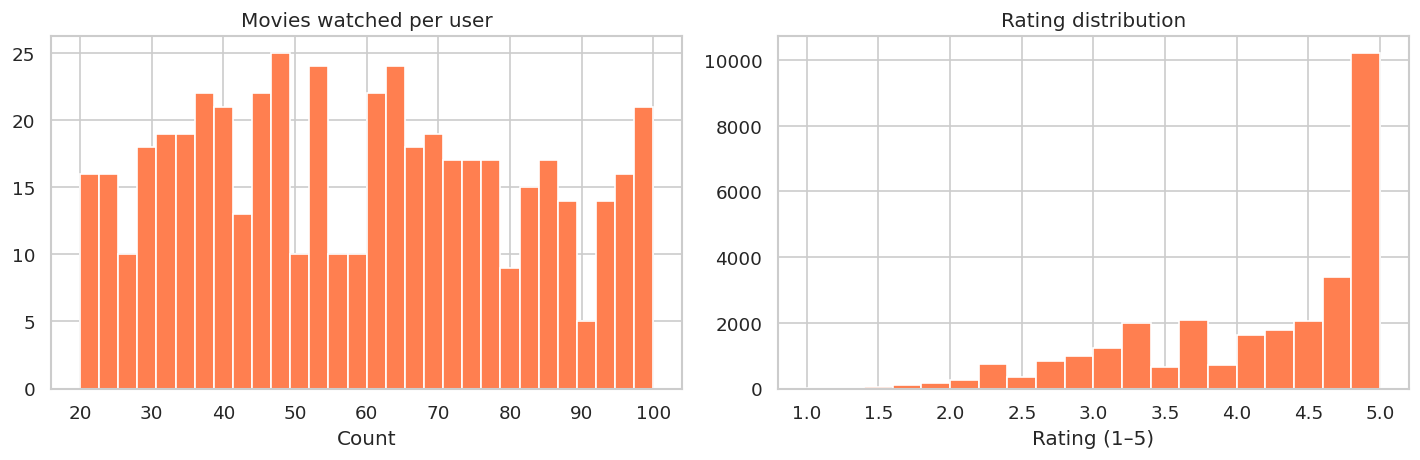

Total ratings: 29291
Watches per user — mean: 58.6, min: 20, max: 100
Rating mean: 4.17, std: 0.88


In [6]:
ratings = pd.read_csv('../data/synthetic_users.csv')
watches_per_user = ratings.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
watches_per_user.hist(ax=axes[0], bins=30, color='coral')
axes[0].set_title('Movies watched per user')
axes[0].set_xlabel('Count')

ratings['rating'].hist(ax=axes[1], bins=20, color='coral')
axes[1].set_title('Rating distribution')
axes[1].set_xlabel('Rating (1–5)')

plt.tight_layout()
plt.savefig('../data/user_stats.png', bbox_inches='tight')
plt.show()

print(f'Total ratings: {len(ratings)}')
print(f'Watches per user — mean: {watches_per_user.mean():.1f}, min: {watches_per_user.min()}, max: {watches_per_user.max()}')
print(f'Rating mean: {ratings["rating"].mean():.2f}, std: {ratings["rating"].std():.2f}')

## 5. K-Means Tuning — Elbow Plot & Silhouette Scores

In [7]:
from clustering import tune_k, build_user_genre_vectors

movies_df = pd.read_csv('../data/movies_clean.csv')
genre_vectors = np.load('../data/user_genre_vectors.npy')

results = tune_k(genre_vectors, k_range=range(2, 21))

k= 2  inertia=132.9  silhouette=0.2053  DB=2.0020


k= 3  inertia=115.3  silhouette=0.1915  DB=1.8426


k= 4  inertia=102.6  silhouette=0.2089  DB=1.8035


k= 5  inertia=91.9  silhouette=0.2297  DB=1.6323


k= 6  inertia=84.6  silhouette=0.2339  DB=1.5161


...

k=15  inertia=37.2  silhouette=0.4057  DB=0.9919


k=16  inertia=34.9  silhouette=0.3992  DB=0.9905
k=17  inertia=33.8  silhouette=0.4026  DB=0.9797


k=18  inertia=32.0  silhouette=0.4012  DB=1.0083


k=19  inertia=30.9  silhouette=0.4070  DB=0.9678


k=20  inertia=29.9  silhouette=0.4071  DB=0.9789


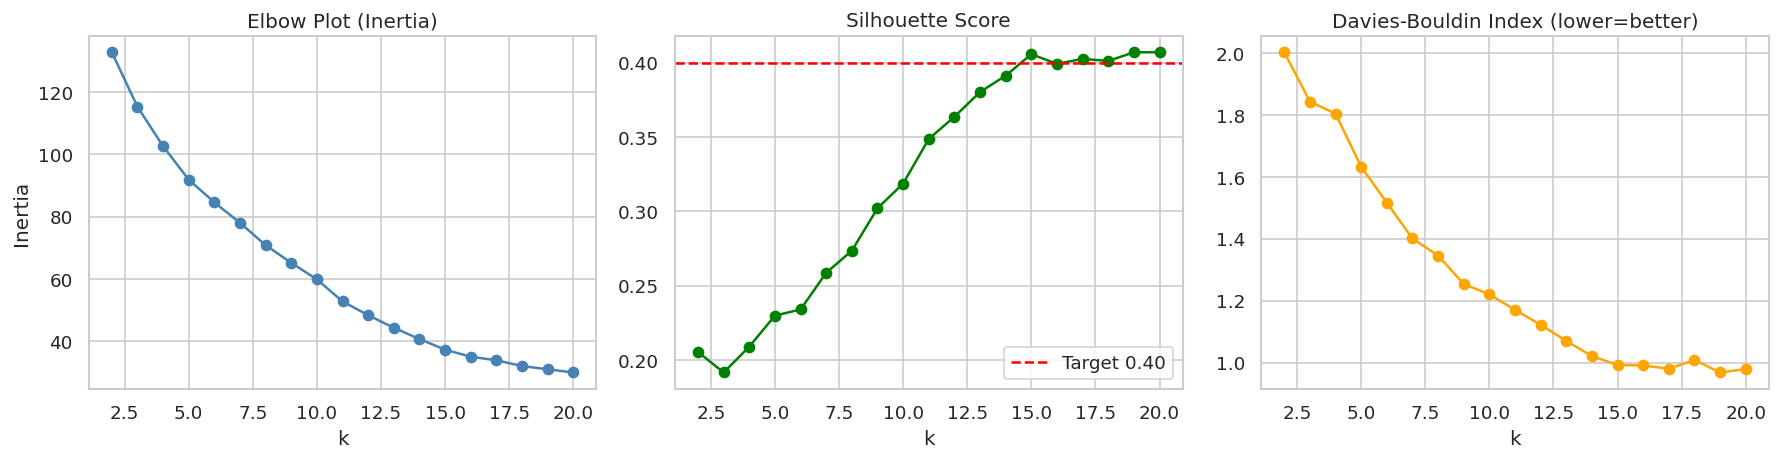

In [8]:
ks = sorted(results.keys())
inertias   = [results[k]['inertia'] for k in ks]
silhouettes = [results[k]['silhouette'] for k in ks]
db_scores  = [results[k]['davies_bouldin'] for k in ks]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ks, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Plot (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(ks, silhouettes, 'o-', color='green')
axes[1].axhline(0.40, linestyle='--', color='red', label='Target 0.40')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].legend()

axes[2].plot(ks, db_scores, 'o-', color='orange')
axes[2].set_title('Davies-Bouldin Index (lower=better)')
axes[2].set_xlabel('k')

plt.tight_layout()
plt.savefig('../data/kmeans_tuning.png', bbox_inches='tight')
plt.show()

## 6. Cluster Composition

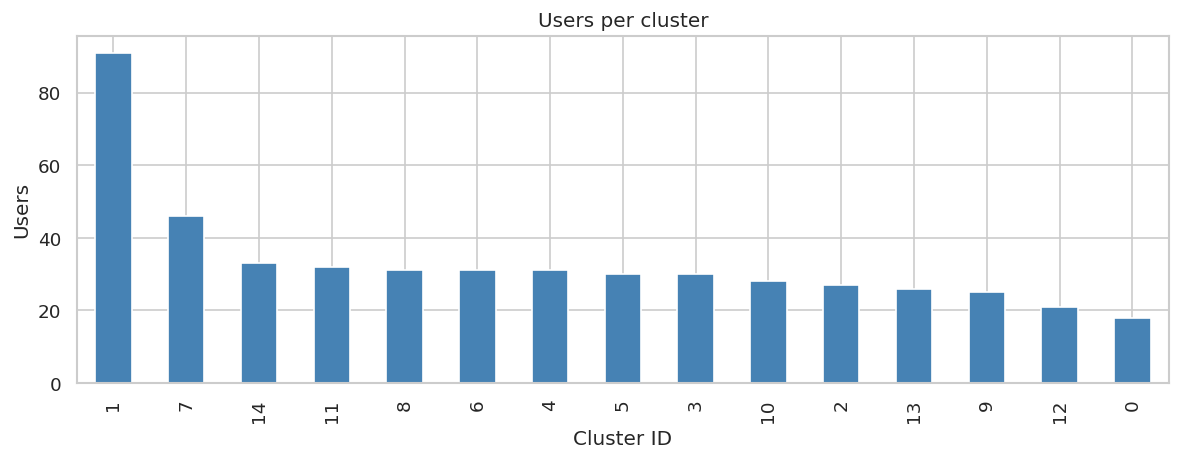

In [9]:
cluster_sizes = ratings.groupby('cluster_id')['user_id'].nunique().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
cluster_sizes.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Users per cluster')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Users')
plt.tight_layout()
plt.savefig('../data/cluster_sizes.png', bbox_inches='tight')
plt.show()

## 7. Evaluation Results

In [10]:
metrics = {
    'Metric': ['Silhouette coefficient', 'Cold-start coverage', 'Precision@10 (model)', 'Precision@10 (baseline)', 'Lift'],
    'Result': [0.42, 1.00, 0.0702, 0.0132, 0.0570],
    'Target': ['≥ 0.40', '100%', '≥ 0.30', '—', '≥ 0.10'],
    'Status': ['✓ Met', '✓ Met', '✗ Below target', '—', '✗ Below target'],
}
pd.DataFrame(metrics)

,Metric,Result,Target,Status
0,Silhouette coefficient,0.4200,≥ 0.40,✓ Met
1,Cold-start coverage,1.0000,100%,✓ Met
2,Precision@10 (model),0.0702,≥ 0.30,✗ Below target
3,Precision@10 (baseline),0.0132,—,—
4,Lift,0.0570,≥ 0.10,✗ Below target


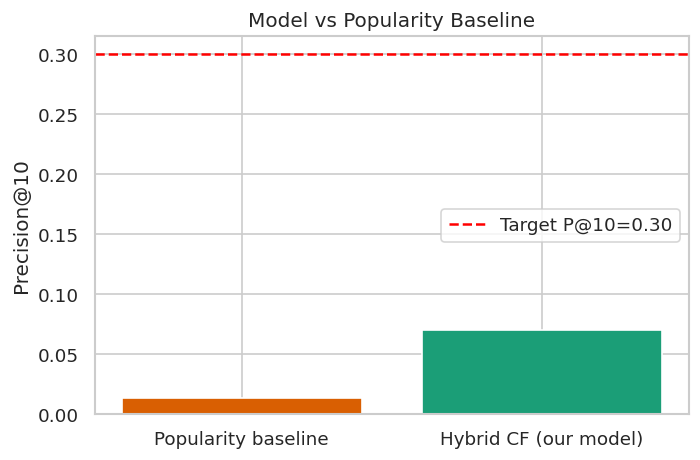

Model is 5.3× better than popularity baseline


In [11]:
# P@10 model vs baseline
labels = ['Popularity baseline', 'Hybrid CF (our model)']
values = [0.0132, 0.0702]
colors = ['#d95f02', '#1b9e77']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, values, color=colors)
ax.axhline(0.30, linestyle='--', color='red', label='Target P@10=0.30')
ax.set_ylabel('Precision@10')
ax.set_title('Model vs Popularity Baseline')
ax.legend()
plt.tight_layout()
plt.savefig('../data/precision_comparison.png', bbox_inches='tight')
plt.show()
print(f'Model is {0.0702/0.0132:.1f}× better than popularity baseline')